# Part 2 - Settlement Classification (Random Forest + GLCM Texture)

This notebook classifies land cover in Nairobi into **3 classes** using a
**supervised Random Forest** classifier trained on Sentinel-2 imagery.

## 3 Land-Cover Classes

| Label | Class        | Description                                         |
|-------|-------------|-----------------------------------------------------|
| 0     | Informal    | Slum / unplanned settlement (e.g. Kibera, Mathare)  |
| 1     | Formal      | Planned residential (e.g. Karen, Runda)        |
| 2     | Other       | Vegetation, park, road, bare soil, water, airport tarmac   |

**Why 3 classes instead of 5?**  
With limited training data, fewer classes = more pixels per class = better accuracy.  
The "other" class absorbs vegetation, water, roads, parks - things that are  
spectrally distinct from built-up areas and easier for the model to learn.  
The model can then focus its capacity on the hard problem: informal vs formal.

## Key Features (18 total)

- **6 spectral bands** (B2, B3, B4, B8, B11, B12)
- **7 spectral indices** (NDVI, NDBI, NDWI, MNDWI, BSI, SAVI, EVI)
- **5 GLCM texture features** (contrast, entropy, homogeneity, correlation, uniformity)

GLCM texture features are **critical** for distinguishing informal from formal
settlements - spectral values alone cannot do this because both are "built-up".
Texture captures the *spatial pattern* of pixels.

## Train Once → Classify Many Years

The pipeline trains the classifier on ONE year's composite, then applies it
to composites from **any other year** - no retraining needed.

All helper functions are in `src/settlement_classifier.py`.

---
## 0 - Setup

In [1]:
import ee
import sys
sys.path.append('../.')

from src.settlement_classifier import *

try:
    ee.Initialize()
except:
    ee.Authenticate()
    ee.Initialize()


---
## 1 - Configuration

Set the **training year** and **target years**.  
Point `TRAINING_GEOJSON` to your own annotated GeoJSON for best results.  
If `None`, the built-in default Nairobi zones are used.

In [5]:
from src.settlement_classifier import CLASS_MAP
# ── CONFIGURATION ──────────────────────────────────────────────────────

TRAINING_YEAR = 2022
TARGET_YEARS = [2020, 2022, 2024]

# Path to custom training GeoJSON. To create one, open geojson.io, 
# draw precise polygons, and point here.
TRAINING_GEOJSON = '../data/geospatial/training_zones_v1.geojson'

N_TREES = 500
CLOUD_PCT = 20

print(f'Training year : {TRAINING_YEAR}')
print(f'Target years  : {TARGET_YEARS}')
print(f'Custom GeoJSON: {TRAINING_GEOJSON or "None (using defaults)"}')
print(f'Classes       : {CLASS_NAMES} ({len(CLASS_NAMES)} classes)')
print(f'RF trees      : {N_TREES}')

Training year : 2022
Target years  : [2020, 2022, 2024]
Custom GeoJSON: ../data/geospatial/training_zones_v1.geojson
Classes       : ['informal', 'formal', 'other'] (3 classes)
RF trees      : 500


---
## 2 - Load Nairobi Boundary

In [6]:
nairobi_boundary = (
    ee.FeatureCollection("projects/ee-nairobi-heatmap/assets/ken_admin2")
    .filter(ee.Filter.eq('adm1_name', 'Nairobi'))
)

---
## 3 - Run the Full Pipeline

The `run_pipeline()` function does everything:  
1. Builds the Sentinel-2 feature composite (18 bands)  
2. Loads training polygons  
3. Samples pixels $\rarr$ train/test split  
4. Trains a Random Forest 
5. Evaluates on held-out test set  
6. Classifies each target year  
7. Displays results  

Takes several minutes due to GEE server-side computations.

Settlement Classification Pipeline
Training year : 2022
Target years  : [2020, 2022, 2024]

[1/7]  Building feature composite for training year 2022…
  [Loading Sentinel-2 composite for 2022]
  [Computing spectral indices]
  [Computing GLCM texture features]

[2/7]  Loading training zones…
  [Skipping feature with unknown class '']
  [Skipping feature with unknown class '']
  [Skipping feature with unknown class '']
  [Skipping feature with unknown class '']
  [Skipping feature with unknown class '']
  [Skipping feature with unknown class '']
  [Skipping feature with unknown class '']
  [Skipping feature with unknown class '']
  [Loaded 48 training zone(s) from ../data/geospatial/training_zones_v1.geojson]

[3/7]  Sampling & splitting data…
  [Sampling pixels from training zones (scale=30m, max=5000)]
  [Total samples: 5000 | Train: 5000 | Test: 0]

[4/7]  Training classifier…
  [Training Random Forest with 500 trees]
  [Classifier trained successfully]

[5/7]  Evaluating accuracy…
  [

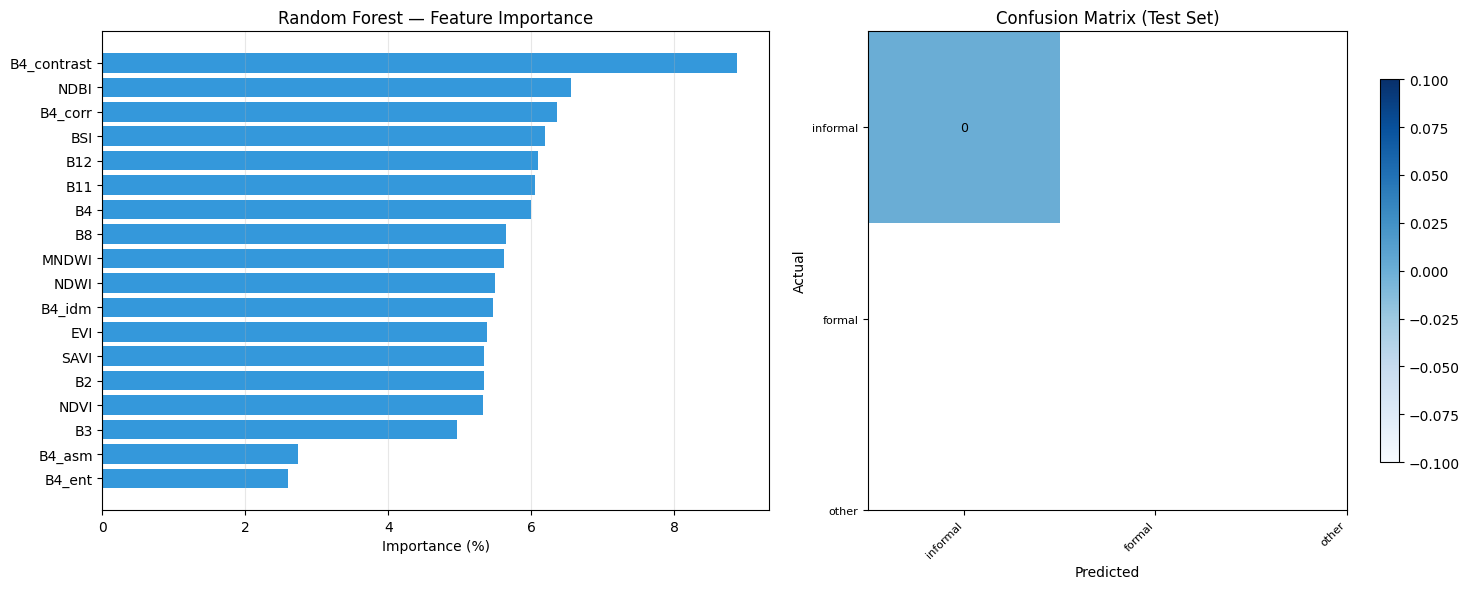

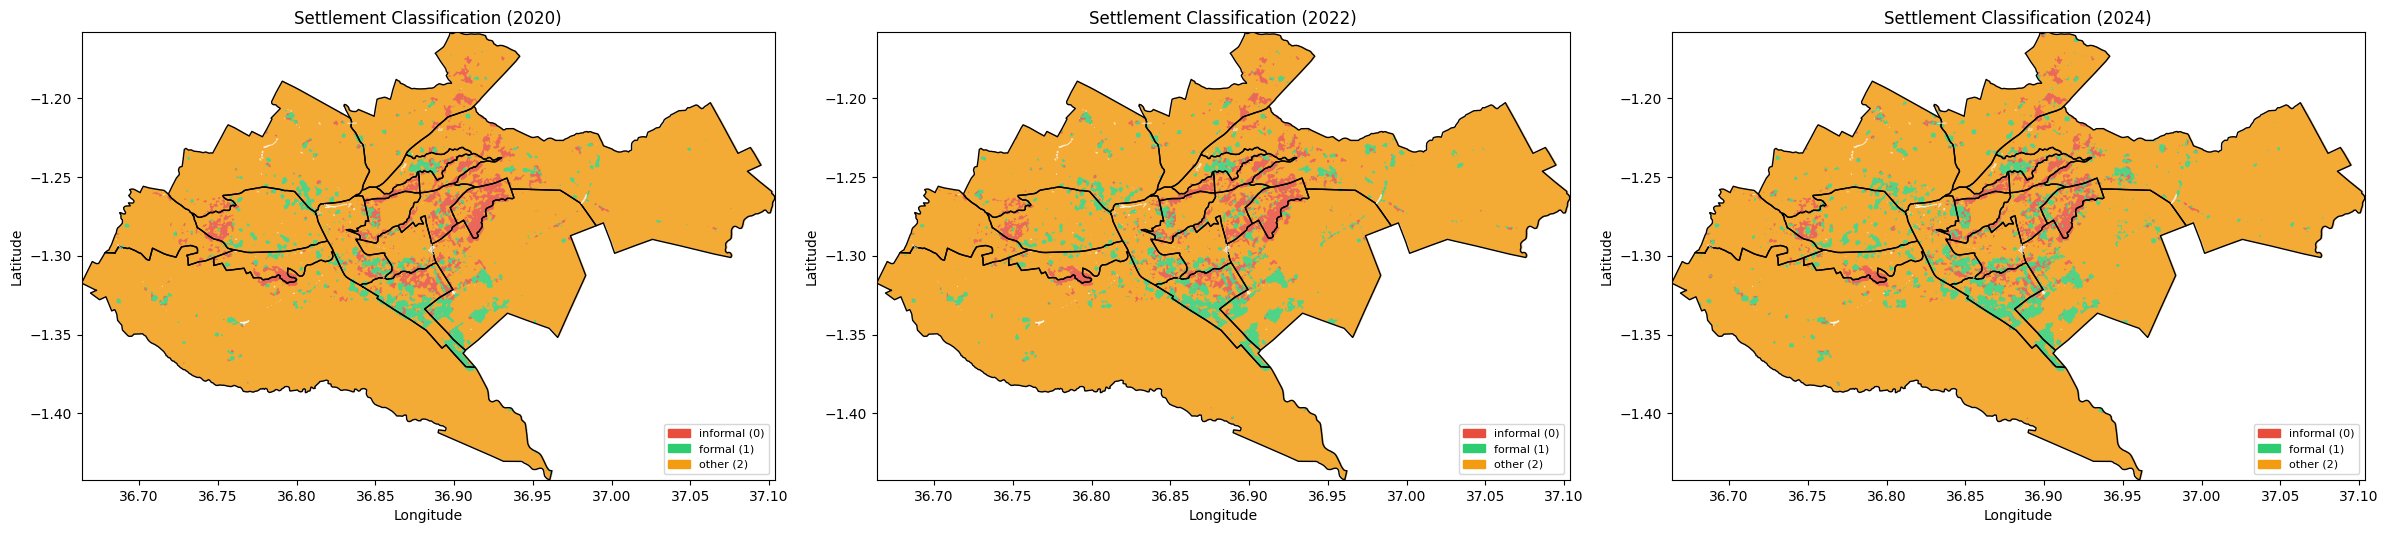


Pipeline complete!


In [8]:
results = run_pipeline(
    roi=nairobi_boundary,
    training_year=TRAINING_YEAR,
    target_years=TARGET_YEARS,
    geojson_path=TRAINING_GEOJSON,
    roads_path='../data/geospatial/major_roads.geojson',  
    n_trees=N_TREES,
    cloud_pct=CLOUD_PCT,
    show_plots=True,
)

---
## 4 - Accuracy Report

**Key metrics:**
- **Overall Accuracy**: % of correctly classified pixels
- **Kappa**: agreement adjusted for chance 
- **Producer's Accuracy**: per-class recall
- **Consumer's Accuracy**: per-class precision

In [5]:
metrics = results['metrics']

print('═' * 50)
print(f"  Overall Accuracy : {metrics['overall_accuracy']:.4f}")
print(f"  Kappa Coefficient: {metrics['kappa']:.4f}")
print('═' * 50)

pa = metrics.get('producers_accuracy', [[]])
ca = metrics.get('consumers_accuracy', [[]])

print('\n  Per-class metrics:')
for i, name in enumerate(CLASS_NAMES):
    try:
        prod = pa[i][0] if i < len(pa) else 'N/A'
        cons = ca[0][i] if i < len(ca[0]) else 'N/A'
        if isinstance(prod, float): prod = f'{prod:.3f}'
        if isinstance(cons, float): cons = f'{cons:.3f}'
        print(f"    {name:12s}  Producer: {prod}  |  Consumer: {cons}")
    except:
        print(f"    {name:12s}  (metrics not available)")

══════════════════════════════════════════════════
  Overall Accuracy : 0.8578
  Kappa Coefficient: 0.7808
══════════════════════════════════════════════════

  Per-class metrics:
    informal      Producer: 0.918  |  Consumer: 0.891
    formal        Producer: 0.944  |  Consumer: 0.782
    other         Producer: 0.661  |  Consumer: 0.932


---
## 5 - Classify a Custom Year

The trained classifier is reusable. Just build a new composite and classify:

Building composite for 2019...
  [Loading Sentinel-2 composite for 2019]
  [Computing spectral indices]
  [Computing GLCM texture features]
Classifying 2019...


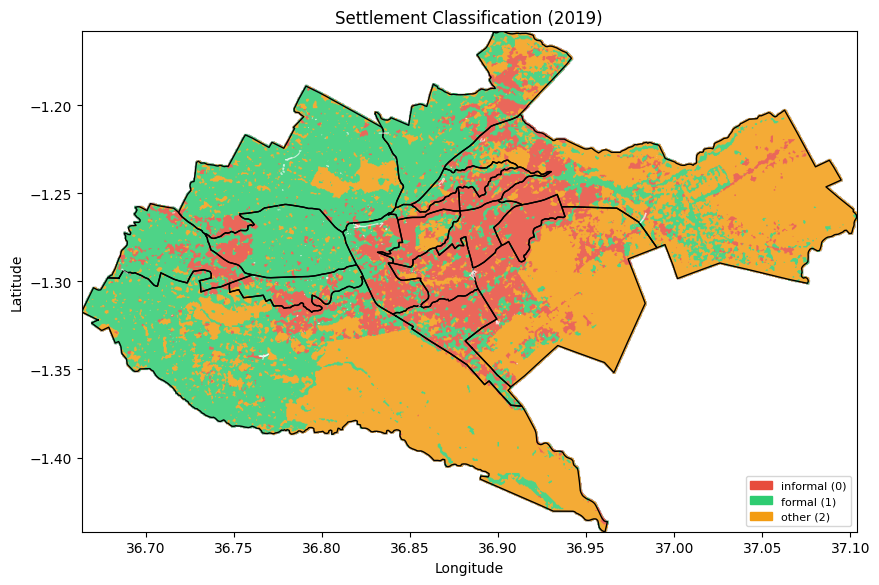

In [6]:
CUSTOM_YEAR = 2019

print(f'Building composite for {CUSTOM_YEAR}...')
composite_custom = build_feature_composite(nairobi_boundary, CUSTOM_YEAR)

print(f'Classifying {CUSTOM_YEAR}...')
classified_custom = classify_image(composite_custom, results['classifier'])

fig, ax = plt.subplots(figsize=(10, 8))
visualize_classification(
    classified_custom, 
    nairobi_boundary, 
    ax=ax, 
    year=CUSTOM_YEAR, 
    roads_path='../data/geospatial/major_roads.geojson'  
)
plt.show()


---
## 6 - How to Improve Accuracy

### 1. Better Training Data (MOST IMPORTANT)
- Open `data/geospatial/training_zones_template.geojson` in [geojson.io](https://geojson.io)
- Draw **precise, irregular** polygons following real boundaries (not squares!)
- **Bigger polygons** = more training pixels = better
- Add more zones per class, especially for under-represented classes
- Set `TRAINING_GEOJSON = '../data/geospatial/my_zones.geojson'`

### 2. Existing Datasets
- **Google Open Buildings** (in GEE) - building density as proxy for settlement type
- **Map Kibera / OpenStreetMap** - community-mapped slum boundaries
- **GHS-BUILT-S 2023** (Copernicus) - global built-up surface at 10m
- **IDEAMAPS Network** - curated informal settlement reference data

### 3. Model Tuning
- Try `N_TREES = 500` for better accuracy (slower)
- Fall back to **binary** (informal vs. not-informal) as 3 classes is still noisy